# 01. Exploratory Data Analysis

This notebook rebuilds the EDA from scratch as a forecasting-first analysis. The goal is to understand the panel structure, train/test support, target and weight behavior, feature quality, temporal dependencies, and the exact reasons later notebooks should favor global point-forecast models.

**Roadmap**
1. Confirm schema and panel structure.
2. Check whether train and test live on the same support.
3. Measure sparsity, coverage, and split feasibility.
4. Analyze target, weight, and feature behavior.
5. Inspect representative time-series patterns and cross-series structure.
6. End with explicit modeling implications.

**Executive summary**
- The dataset is a large panel with 23 `code`s, 180 train `sub_code`s, 5 `sub_category` buckets, and 4 horizons.
- Test support is narrower than train support, so generalization across uneven series coverage matters.
- The metric is heavily weight-driven, so unweighted error summaries are not enough.
- The current project workflow is point-forecast only; there are no saved quantiles, prediction intervals, or interval metrics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.tsa.seasonal import STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

PROJECT_ROOT = Path.cwd() if (Path.cwd() / 'data').exists() else Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data/ts-forecasting'
VAL_CUTOFF = 2880
SEED = 42
rng = np.random.default_rng(SEED)

train = pd.read_parquet(DATA_DIR / 'train.parquet')
test = pd.read_parquet(DATA_DIR / 'test.parquet')
feature_cols = [c for c in train.columns if c.startswith('feature_')]
series_keys = ['code', 'sub_code', 'sub_category', 'horizon']

def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

train.head()


,id,code,sub_code,sub_category,horizon,ts_index,feature_a,feature_b,feature_c,feature_d,...,feature_ca,feature_cb,feature_cc,feature_cd,feature_ce,feature_cf,feature_cg,feature_ch,y_target,weight
0,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,89,29,16.364093,7.464023,5.966933,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.551324,40.982572
1,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__1__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,1,89,53,2.858806,5.050617,15.906651,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.315583,150.075406
2,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__3__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,3,89,51,9.585452,1.076268,9.004147,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.362894,115.953552
3,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__10__89,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,10,89,44,8.840588,15.034634,4.170780,...,-0.001686,-0.105328,-0.005045,NaN,-0.133697,2.849819,0.112068,1,-0.667023,64.573073
4,W2MW3G2L__J0G2B0KU__PZ9S1Z4V__25__90,W2MW3G2L,J0G2B0KU,PZ9S1Z4V,25,90,28,2.303825,7.696209,12.896100,...,-0.001622,-0.103809,-0.005135,NaN,-0.174660,2.738606,0.109204,1,-0.437398,41.948761


## 1. Dataset schema and panel structure

We start by verifying the schema, key columns, and the basic size of the panel. This matters because all later notebooks assume a global panel forecasting setup rather than isolated single-series modeling.


In [2]:
overview = {
    'train_rows': len(train),
    'test_rows': len(test),
    'train_columns': len(train.columns),
    'test_columns': len(test.columns),
    'feature_count': len(feature_cols),
    'code_count': train['code'].nunique(),
    'train_sub_code_count': train['sub_code'].nunique(),
    'test_sub_code_count': test['sub_code'].nunique(),
    'sub_category_count': train['sub_category'].nunique(),
    'horizons': sorted(train['horizon'].unique().tolist()),
    'ts_index_range_train': (int(train['ts_index'].min()), int(train['ts_index'].max())),
    'ts_index_range_test': (int(test['ts_index'].min()), int(test['ts_index'].max())),
}
overview


{'train_rows': 5337414,
 'test_rows': 1447107,
 'train_columns': 94,
 'test_columns': 92,
 'feature_count': 86,
 'code_count': 23,
 'train_sub_code_count': 180,
 'test_sub_code_count': 47,
 'sub_category_count': 5,
 'horizons': [1, 3, 10, 25],
 'ts_index_range_train': (1, 3601),
 'ts_index_range_test': (3602, 4376)}

The raw schema confirms a large multi-index panel. The important point is that there are many more train `sub_code`s than test `sub_code`s, so support mismatch is part of the problem, not a nuisance detail.


## 2. Train vs test comparability

Before looking at target behavior, we should check whether train and test are drawn from the same support. If train covers entities or time ranges that test does not, the forecasting pipeline has to be robust to that mismatch.


In [3]:
train_only = sorted(set(train.columns) - set(test.columns))
test_only = sorted(set(test.columns) - set(train.columns))
comparability = pd.DataFrame([
    {'column': 'code', 'train_nunique': train['code'].nunique(), 'test_nunique': test['code'].nunique()},
    {'column': 'sub_code', 'train_nunique': train['sub_code'].nunique(), 'test_nunique': test['sub_code'].nunique()},
    {'column': 'sub_category', 'train_nunique': train['sub_category'].nunique(), 'test_nunique': test['sub_category'].nunique()},
    {'column': 'horizon', 'train_nunique': train['horizon'].nunique(), 'test_nunique': test['horizon'].nunique()},
    {'column': 'ts_index', 'train_nunique': train['ts_index'].nunique(), 'test_nunique': test['ts_index'].nunique()},
])
print({'train_only_columns': train_only, 'test_only_columns': test_only})
comparability


{'train_only_columns': ['weight', 'y_target'], 'test_only_columns': []}


,column,train_nunique,test_nunique
0,code,23,23
1,sub_code,180,47
2,sub_category,5,5
3,horizon,4,4
4,ts_index,3601,775


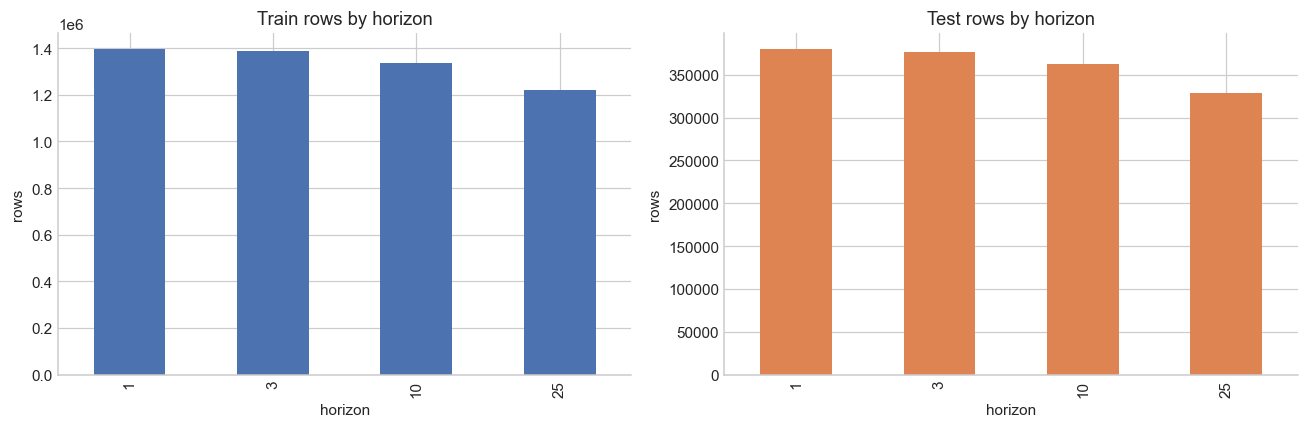

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['horizon'].value_counts().sort_index().plot.bar(ax=axes[0], color='#4C72B0')
axes[0].set_title('Train rows by horizon')
axes[0].set_xlabel('horizon')
axes[0].set_ylabel('rows')

test['horizon'].value_counts().sort_index().plot.bar(ax=axes[1], color='#DD8452')
axes[1].set_title('Test rows by horizon')
axes[1].set_xlabel('horizon')
axes[1].set_ylabel('rows')
plt.tight_layout()
plt.show()


In [5]:
feature_sample = rng.choice(feature_cols, size=min(8, len(feature_cols)), replace=False)
summary_rows = []
for col in feature_sample:
    summary_rows.append({
        'feature': col,
        'train_mean': float(train[col].mean()),
        'test_mean': float(test[col].mean()),
        'train_std': float(train[col].std()),
        'test_std': float(test[col].std()),
        'train_missing': float(train[col].isna().mean()),
        'test_missing': float(test[col].isna().mean()),
    })
feature_drift_preview = pd.DataFrame(summary_rows)
feature_drift_preview


,feature,train_mean,test_mean,train_std,test_std,train_missing,test_missing
0,feature_cg,1.062790,1.524774,1.303983,1.739919,0.007428,0.000609
1,feature_bh,415357.932409,432872.629161,875394.693880,857840.523332,0.000000,0.000609
2,feature_bu,-2.131990,-1.856484,1.596166,1.609053,0.000000,0.000609
3,feature_bb,7172.929540,3388.069029,33321.145665,17154.293696,0.000000,0.000672
4,feature_ce,-0.022882,-0.017241,0.172899,0.133421,0.051678,0.035255
5,feature_aj,0.901724,1.031892,1.446564,1.503979,0.001522,0.000000
6,feature_h,0.005912,0.005647,0.007924,0.007859,0.010954,0.000124
7,feature_bj,9361.198237,15424.722505,31236.411006,54407.488838,0.000007,0.000609


Train and test are structurally aligned at the schema level, but they are not identical in support. In particular, the smaller test `sub_code` universe means generalization across uneven panel coverage should be treated as a core modeling requirement.


## 3. Series coverage, sparsity, and split feasibility

Forecasting quality depends on whether each series has enough history and whether it crosses the validation cutoff. This section checks how sparse the panel is and how many series are actually eligible for temporal validation.


In [6]:
series_stats = (
    train.groupby(series_keys)
         .agg(length=('ts_index', 'size'), start=('ts_index', 'min'), end=('ts_index', 'max'))
         .reset_index()
)
series_stats['crosses_cutoff'] = (series_stats['start'] <= VAL_CUTOFF) & (series_stats['end'] > VAL_CUTOFF)
series_stats[['length', 'start', 'end']].describe().T


,count,mean,std,min,25%,50%,75%,max
length,36923.0,144.555264,56.770160,1.0,104.0,166.0,194.0,213.0
start,36923.0,1894.655716,1045.470184,1.0,1031.0,1968.0,2787.0,3600.0
end,36923.0,2046.371124,1045.023400,1.0,1181.0,2127.0,2948.0,3601.0


In [7]:
coverage_summary = {
    'total_series': int(len(series_stats)),
    'series_crossing_cutoff': int(series_stats['crosses_cutoff'].sum()),
    'rows_pre_cutoff': int((train['ts_index'] <= VAL_CUTOFF).sum()),
    'rows_post_cutoff': int((train['ts_index'] > VAL_CUTOFF).sum()),
}
coverage_summary


{'total_series': 36923,
 'series_crossing_cutoff': 1930,
 'rows_pre_cutoff': 4121749,
 'rows_post_cutoff': 1215665}

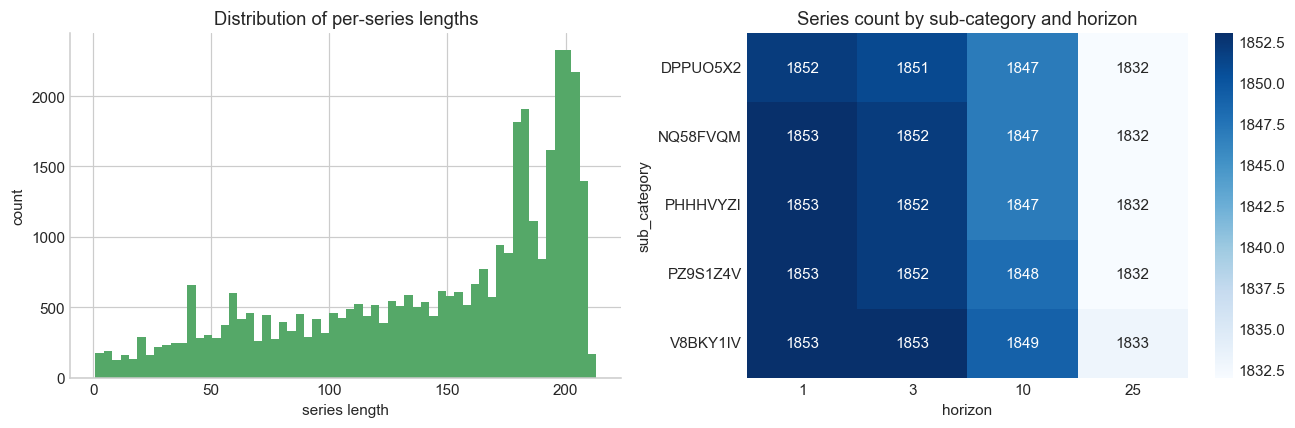

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(series_stats['length'], bins=60, color='#55A868')
axes[0].set_title('Distribution of per-series lengths')
axes[0].set_xlabel('series length')
axes[0].set_ylabel('count')

pivot_density = series_stats.pivot_table(index='sub_category', columns='horizon', values='length', aggfunc='count', fill_value=0)
sns.heatmap(pivot_density, annot=True, fmt='g', cmap='Blues', ax=axes[1])
axes[1].set_title('Series count by sub-category and horizon')
plt.tight_layout()
plt.show()


The panel is broad but uneven. Most series are relatively short, and only a minority cross the validation cutoff cleanly. That makes split discipline important: later notebooks cannot assume every series contributes equally to post-cutoff evaluation.


## 4. Target distribution and outlier behavior

The target drives the final metric, so we need to know whether its scale is stable, whether it is centered, and how severe the tails are. This directly affects baseline choice, loss sensitivity, and interpretation of RMSE-style metrics.


In [9]:
target_stats = train['y_target'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
target_stats


count    5.337414e+06
mean    -6.659048e-01
std      3.252764e+01
min     -2.201882e+03
1%      -8.279722e+01
5%      -7.606810e+00
25%     -1.290776e-01
50%     -5.774818e-04
75%      5.106807e-02
95%      4.504747e+00
99%      6.292342e+01
max      2.314411e+03
Name: y_target, dtype: float64

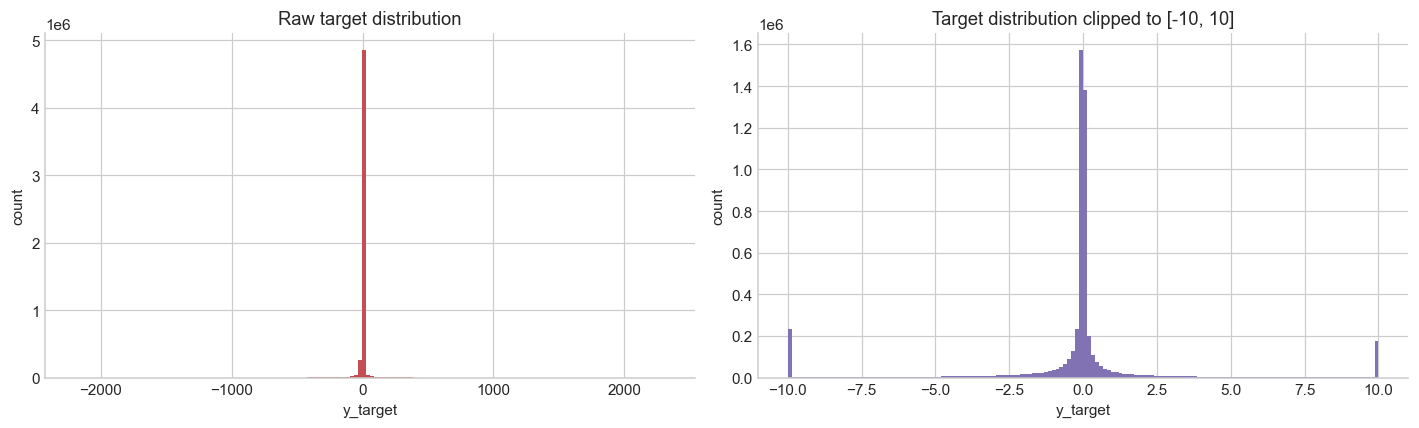

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(train['y_target'], bins=150, color='#C44E52')
axes[0].set_title('Raw target distribution')
axes[0].set_xlabel('y_target')
axes[0].set_ylabel('count')

axes[1].hist(np.clip(train['y_target'], -10, 10), bins=150, color='#8172B3')
axes[1].set_title('Target distribution clipped to [-10, 10]')
axes[1].set_xlabel('y_target')
axes[1].set_ylabel('count')
plt.tight_layout()
plt.show()


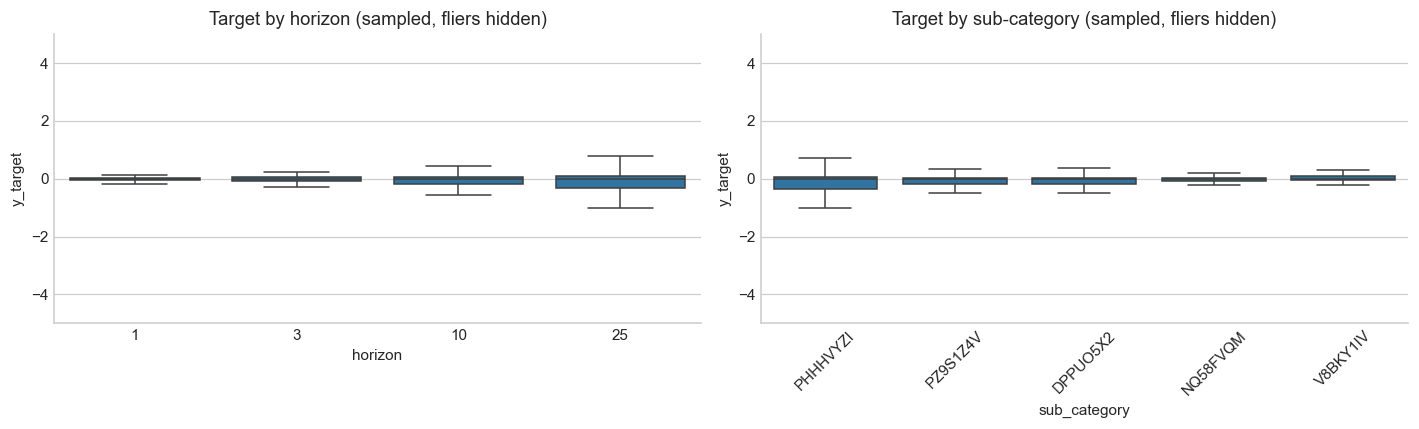

In [11]:
sample_for_boxes = train[['horizon', 'sub_category', 'y_target']].sample(120_000, random_state=SEED)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxplot(data=sample_for_boxes, x='horizon', y='y_target', ax=axes[0], showfliers=False)
axes[0].set_title('Target by horizon (sampled, fliers hidden)')
axes[0].set_ylim(-5, 5)

sub_order = sample_for_boxes.groupby('sub_category')['y_target'].median().sort_values().index
sns.boxplot(data=sample_for_boxes, x='sub_category', y='y_target', ax=axes[1], order=sub_order, showfliers=False)
axes[1].set_title('Target by sub-category (sampled, fliers hidden)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(-5, 5)
plt.tight_layout()
plt.show()


The target is centered near zero but has heavy tails. That means average behavior and extreme behavior can point in different directions, which is exactly why the metric and the weighting scheme need to be treated jointly.


## 5. Weight distribution and metric implications

The competition score is weighted, so a small subset of rows may dominate model ranking. We quantify concentration directly and compare weighted and unweighted target behavior.


In [12]:
weight_rank = train[['weight']].sort_values('weight', ascending=False).reset_index(drop=True)
weight_rank['cum_share'] = weight_rank['weight'].cumsum() / weight_rank['weight'].sum()
positions = {
    'top_1pct_weight_share': float(weight_rank.iloc[max(int(len(weight_rank) * 0.01) - 1, 0)]['cum_share']),
    'top_5pct_weight_share': float(weight_rank.iloc[max(int(len(weight_rank) * 0.05) - 1, 0)]['cum_share']),
    'top_10pct_weight_share': float(weight_rank.iloc[max(int(len(weight_rank) * 0.10) - 1, 0)]['cum_share']),
    'median_weight': float(train['weight'].median()),
    'max_weight': float(train['weight'].max()),
}
positions


{'top_1pct_weight_share': 0.6418612969643038,
 'top_5pct_weight_share': 0.9258065005764631,
 'top_10pct_weight_share': 0.9833170811354748,
 'median_weight': 1699.3843705131449,
 'max_weight': 13912217783333.135}

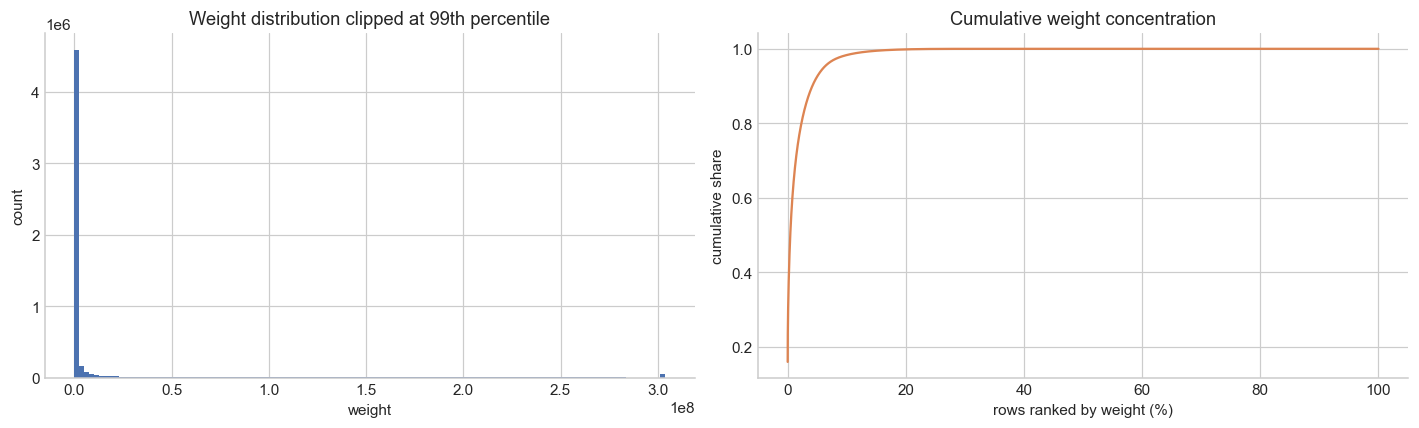

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(np.clip(train['weight'], 0, train['weight'].quantile(0.99)), bins=120, color='#4C72B0')
axes[0].set_title('Weight distribution clipped at 99th percentile')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('count')

axes[1].plot(np.linspace(0, 100, len(weight_rank)), weight_rank['cum_share'], color='#DD8452')
axes[1].set_title('Cumulative weight concentration')
axes[1].set_xlabel('rows ranked by weight (%)')
axes[1].set_ylabel('cumulative share')
plt.tight_layout()
plt.show()


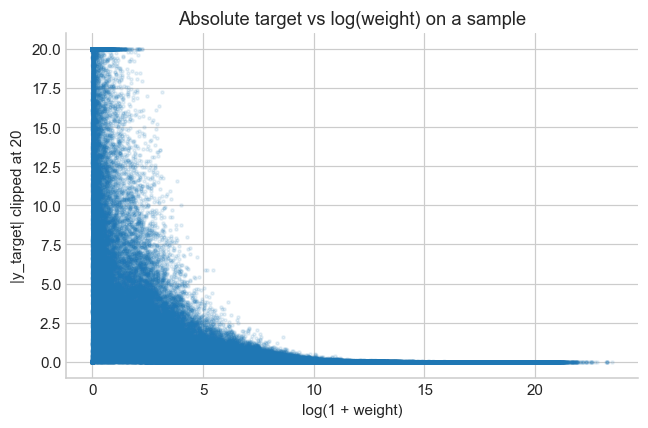

,metric,value
0,"corr(weight, |target|)",-0.019640
1,"corr(log(weight), |target|)",-0.241289


In [14]:
weight_vs_target = train[['weight', 'y_target']].sample(200_000, random_state=SEED).copy()
weight_vs_target['abs_target'] = weight_vs_target['y_target'].abs()
weight_vs_target['log_weight'] = np.log1p(weight_vs_target['weight'])

corr_table = pd.DataFrame({
    'metric': ['corr(weight, |target|)', 'corr(log(weight), |target|)'],
    'value': [
        float(weight_vs_target['weight'].corr(weight_vs_target['abs_target'])),
        float(weight_vs_target['log_weight'].corr(weight_vs_target['abs_target'])),
    ]
})
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(weight_vs_target['log_weight'], weight_vs_target['abs_target'].clip(0, 20), s=4, alpha=0.1)
ax.set_title('Absolute target vs log(weight) on a sample')
ax.set_xlabel('log(1 + weight)')
ax.set_ylabel('|y_target| clipped at 20')
plt.tight_layout()
plt.show()

corr_table


Weight concentration is strong enough that a model can look acceptable under plain summaries and still fail the true project objective. This is one of the main reasons the later notebooks should prioritize weighted evaluation over cosmetic unweighted diagnostics.


## 6. Feature audit

The features are mostly opaque by name, so the EDA should focus on statistical behavior: missingness, scale, correlation, and whether obvious degeneracies exist.


In [15]:
missing_rates = train[feature_cols].isna().mean().sort_values(ascending=False)
variability = train[feature_cols].std(numeric_only=True).sort_values(ascending=False)
constant_count = int((train[feature_cols].nunique(dropna=False) <= 1).sum())

feature_audit = pd.DataFrame({
    'top_missing_feature': missing_rates.head(10).index,
    'missing_rate': missing_rates.head(10).values,
})
print({'constant_feature_count': constant_count})
feature_audit


{'constant_feature_count': 0}


,top_missing_feature,missing_rate
0,feature_at,0.124719
1,feature_by,0.110192
2,feature_ay,0.085420
3,feature_cd,0.074964
4,feature_ce,0.051678
5,feature_cf,0.044289
6,feature_al,0.042233
7,feature_aw,0.038444
8,feature_bz,0.028426
9,feature_bi,0.027622


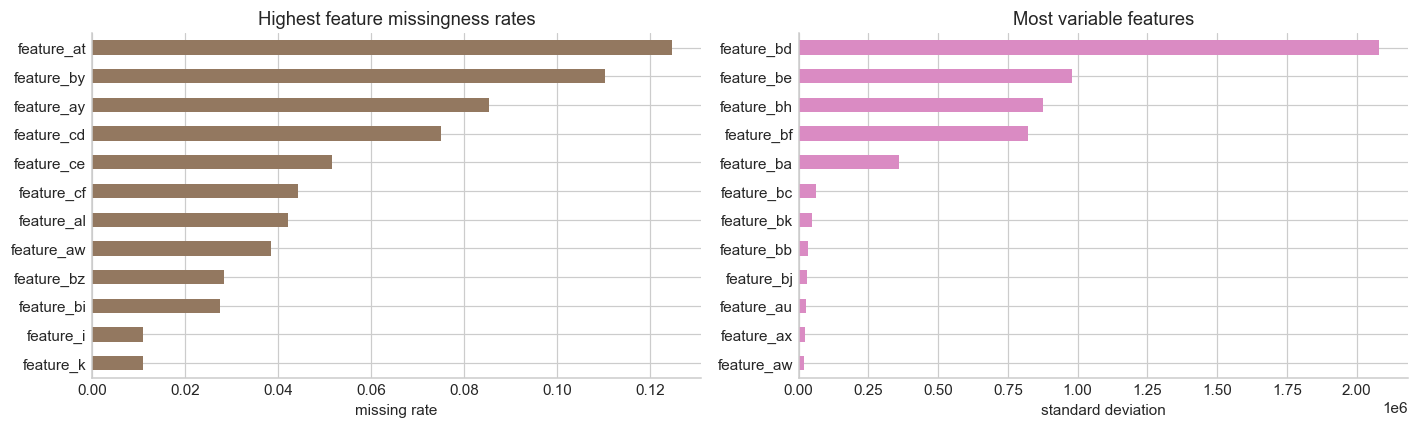

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
missing_rates.head(12).sort_values().plot.barh(ax=axes[0], color='#937860')
axes[0].set_title('Highest feature missingness rates')
axes[0].set_xlabel('missing rate')

variability.head(12).sort_values().plot.barh(ax=axes[1], color='#DA8BC3')
axes[1].set_title('Most variable features')
axes[1].set_xlabel('standard deviation')
plt.tight_layout()
plt.show()


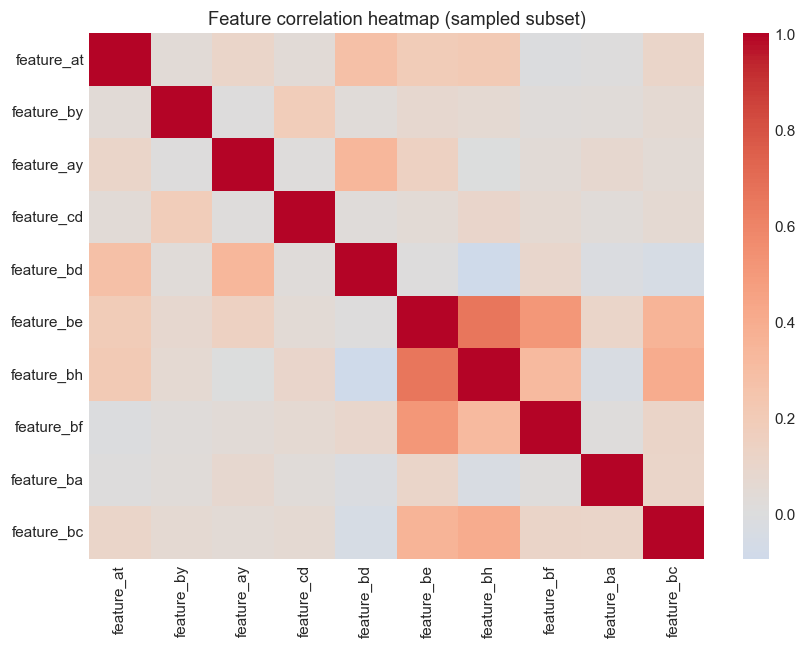

In [17]:
feature_sample = train[feature_cols].sample(80_000, random_state=SEED)
selected_for_corr = list(missing_rates.head(4).index) + list(variability.head(6).index)
selected_for_corr = list(dict.fromkeys(selected_for_corr))[:10]
feature_corr = feature_sample[selected_for_corr].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(feature_corr, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Feature correlation heatmap (sampled subset)')
plt.tight_layout()
plt.show()


There are no constant features, but missingness and scale vary meaningfully across the feature set. That supports the later choice of robust global ML models, and it also warns against over-interpreting raw feature magnitudes without preprocessing awareness.


## 7. Representative series behavior

Instead of showing arbitrary series, we deliberately choose examples that illustrate different modeling pressures: longest history, high cumulative weight, high volatility, and relatively stable behavior.


In [18]:
series_enriched = (
    train.groupby(series_keys)
         .agg(
             length=('ts_index', 'size'),
             min_ts=('ts_index', 'min'),
             max_ts=('ts_index', 'max'),
             total_weight=('weight', 'sum'),
             target_std=('y_target', 'std'),
             target_mean=('y_target', 'mean'),
         )
         .reset_index()
)
series_enriched['target_std'] = series_enriched['target_std'].fillna(0.0)
series_enriched['crosses_cutoff'] = (series_enriched['min_ts'] <= VAL_CUTOFF) & (series_enriched['max_ts'] > VAL_CUTOFF)

representative_pool = series_enriched[(series_enriched['crosses_cutoff']) & (series_enriched['length'] >= 120)].copy()
stable_pool = representative_pool[representative_pool['target_std'] > 0].copy()

chosen = pd.concat([
    representative_pool.nlargest(1, 'length').assign(reason='longest history'),
    representative_pool.nlargest(1, 'total_weight').assign(reason='highest total weight'),
    representative_pool.nlargest(1, 'target_std').assign(reason='most volatile'),
    stable_pool.nsmallest(1, 'target_std').assign(reason='most stable'),
], ignore_index=True).drop_duplicates(subset=series_keys)
chosen[[*series_keys, 'reason', 'length', 'min_ts', 'max_ts', 'total_weight', 'target_std']]

,code,sub_code,sub_category,horizon,reason,length,min_ts,max_ts,total_weight,target_std
0,X9BZ68VQ,OYJGNSQK,DPPUO5X2,1,longest history,212,2826,3037,9.060035e+02,2.641558
1,SJZP0OVU,OYJGNSQK,NQ58FVQM,25,highest total weight,156,2874,3032,4.349747e+10,0.000394
2,W4S29LF4,KL66VIS3,PHHHVYZI,25,most volatile,162,2747,2911,4.562944e-01,296.760011
3,SJZP0OVU,OYJGNSQK,NQ58FVQM,1,most stable,170,2874,3052,3.869062e+10,0.000139


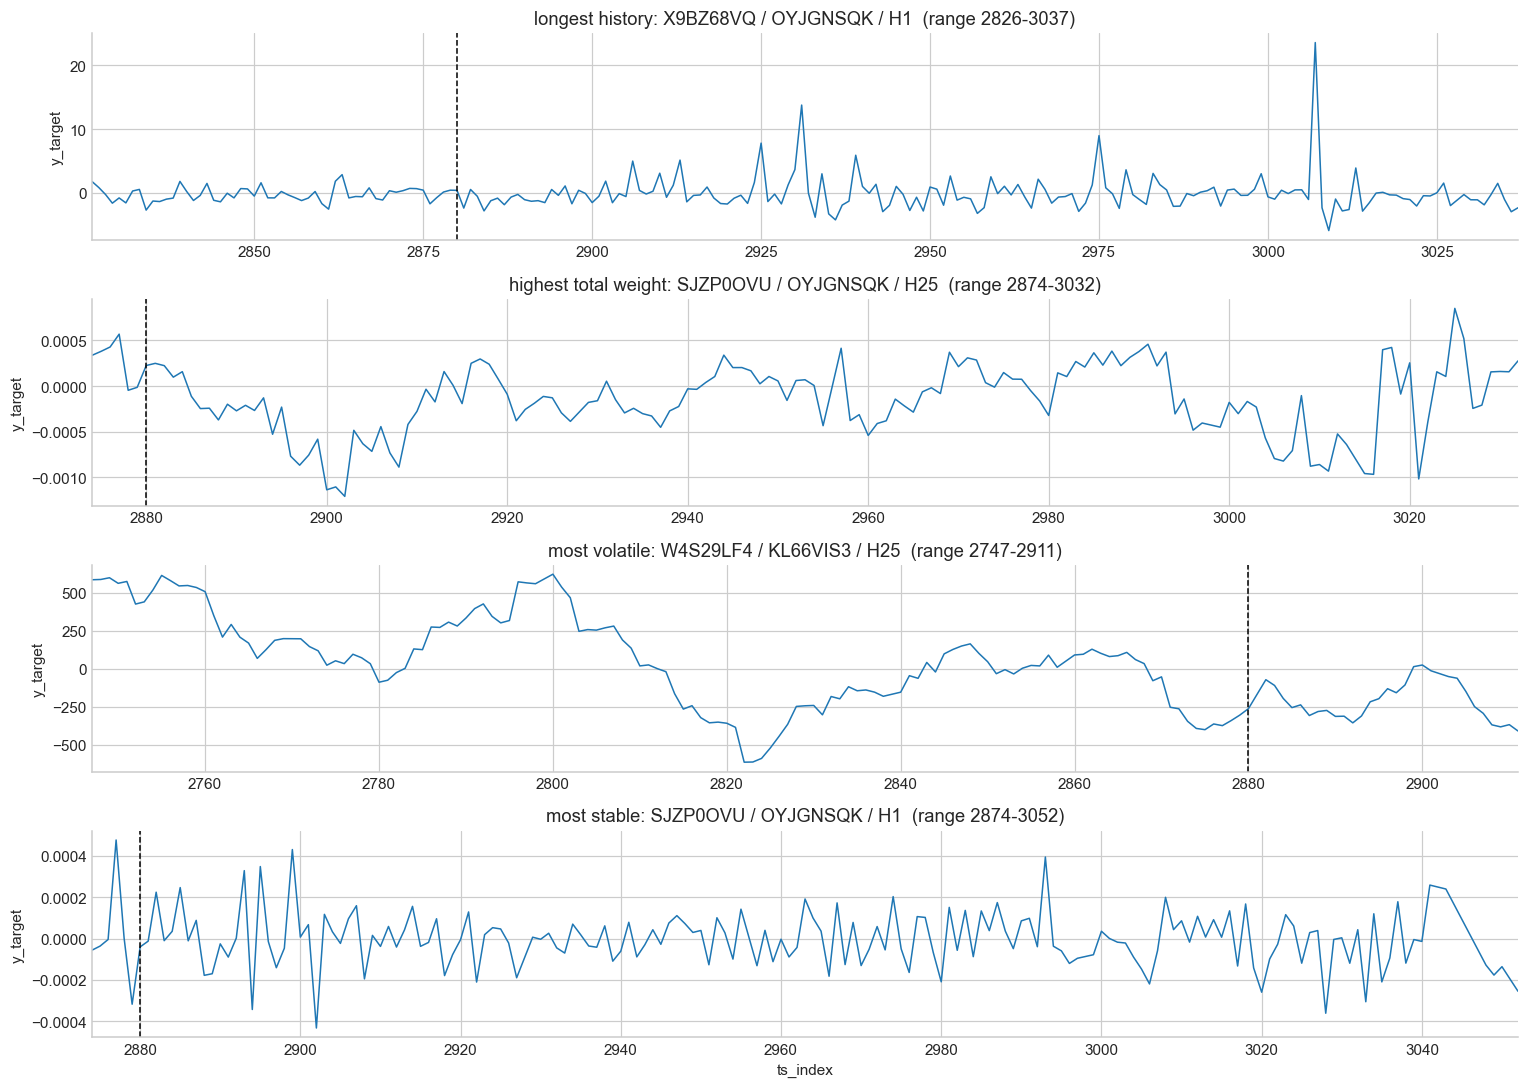

In [19]:
fig, axes = plt.subplots(len(chosen), 1, figsize=(14, 10), sharex=False)
axes = np.atleast_1d(axes)
for ax, row in zip(axes, chosen.itertuples(index=False)):
    mask = (
        (train['code'] == row.code)
        & (train['sub_code'] == row.sub_code)
        & (train['sub_category'] == row.sub_category)
        & (train['horizon'] == row.horizon)
    )
    s = train.loc[mask, ['ts_index', 'y_target']].sort_values('ts_index')
    ax.plot(s['ts_index'], s['y_target'], linewidth=1)
    ax.axvline(VAL_CUTOFF, color='black', linestyle='--', linewidth=1)
    ax.set_xlim(s['ts_index'].min(), s['ts_index'].max())
    ax.set_title(f'{row.reason}: {row.code} / {row.sub_code} / H{row.horizon}  (range {row.min_ts}-{row.max_ts})')
    ax.set_ylabel('y_target')
axes[-1].set_xlabel('ts_index')
plt.tight_layout()
plt.show()

These examples are now restricted to series that are long enough and actually cross the validation cutoff. That makes the split marker meaningful and avoids the earlier problem where short or early-ending series left most of the panel blank.

## 8. Temporal structure: STL, ACF, and PACF

We now inspect one long, validation-feasible anchor series to visualize trend, seasonality, and serial dependence. This is an illustrative diagnostic rather than a claim that every series shares the same decomposition.


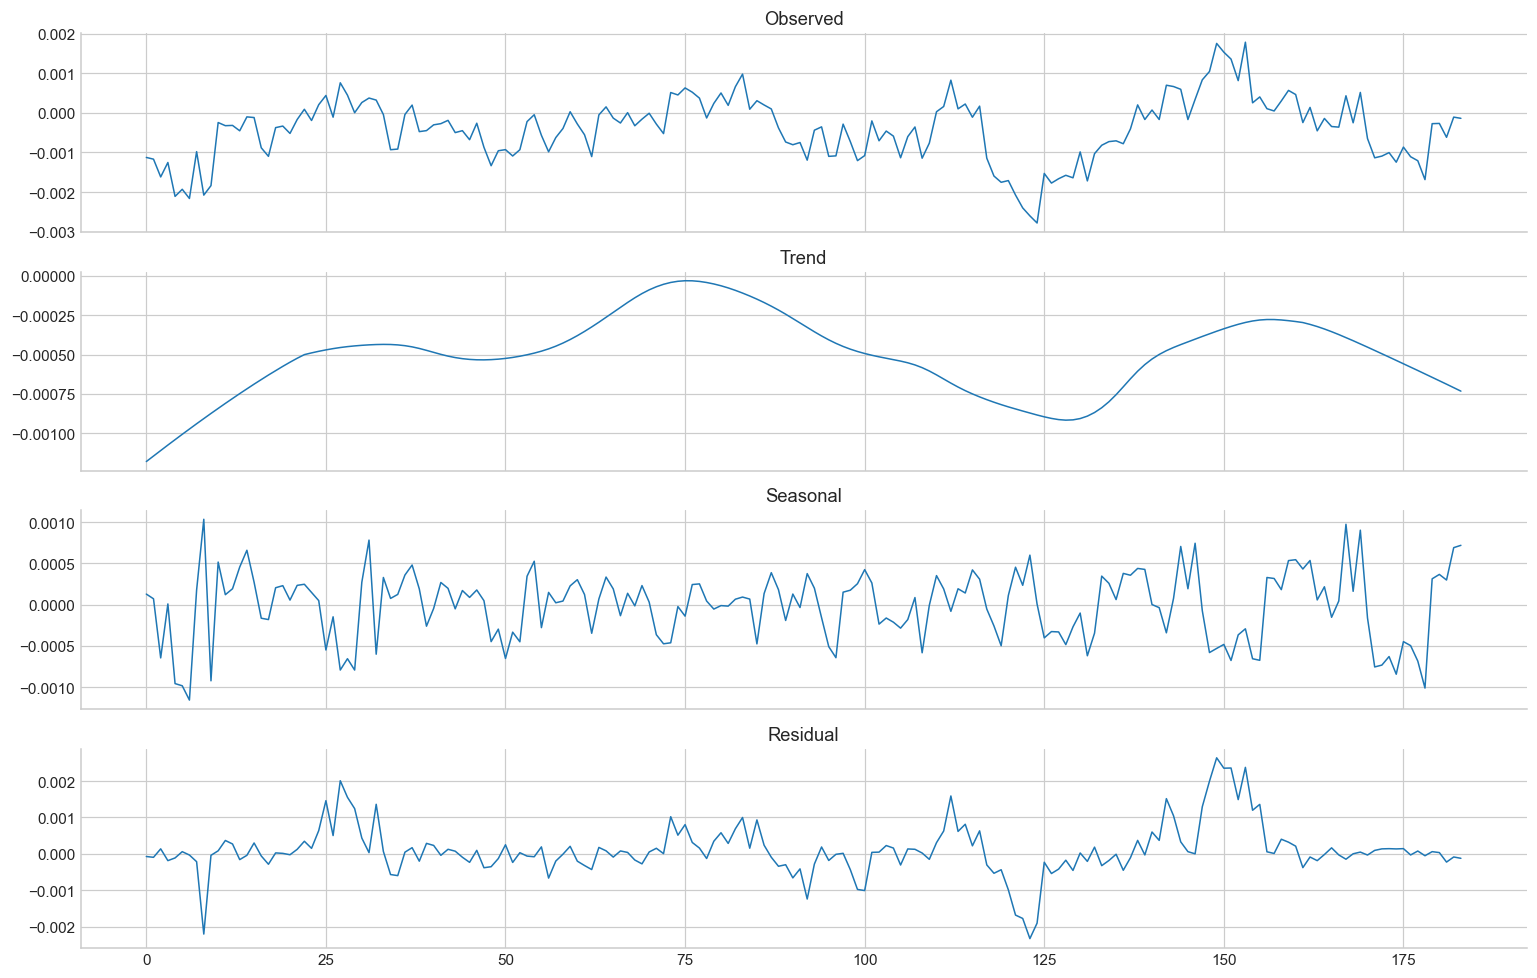

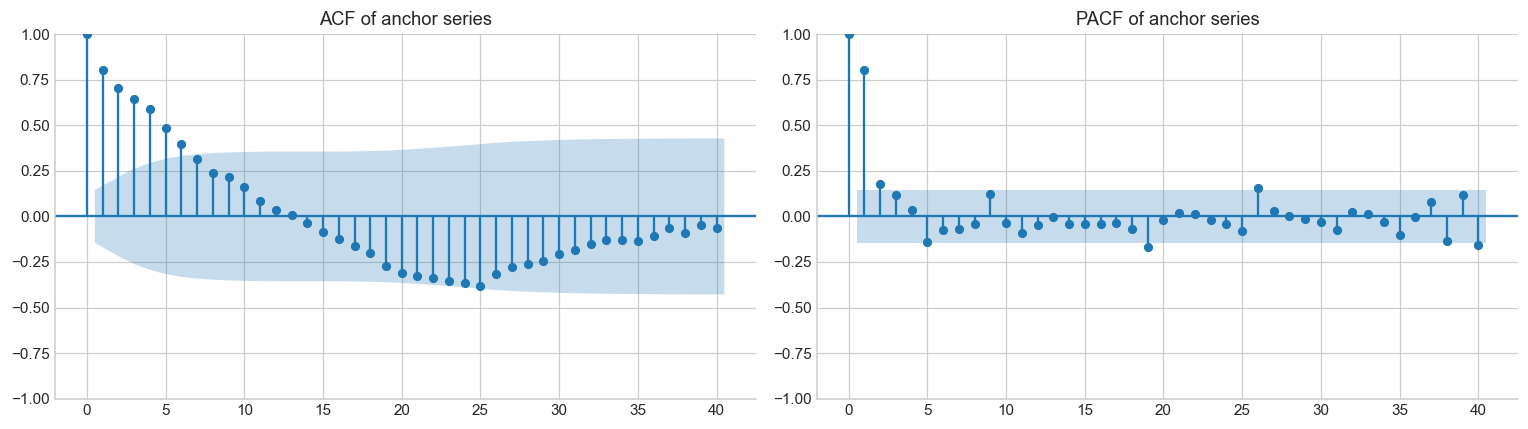

In [20]:
anchor = (
    series_enriched.query('length >= 180')
                   .sort_values(['total_weight', 'length'], ascending=False)
                   .iloc[0]
)
anchor_mask = (
    (train['code'] == anchor['code'])
    & (train['sub_code'] == anchor['sub_code'])
    & (train['sub_category'] == anchor['sub_category'])
    & (train['horizon'] == anchor['horizon'])
)
anchor_series = train.loc[anchor_mask, ['ts_index', 'y_target']].sort_values('ts_index')['y_target'].reset_index(drop=True)
period = max(2, min(24, len(anchor_series) // 8))
stl = STL(anchor_series, period=period, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
for ax, comp, title in zip(axes, [anchor_series, stl.trend, stl.seasonal, stl.resid], ['Observed', 'Trend', 'Seasonal', 'Residual']):
    ax.plot(comp, linewidth=1)
    ax.set_title(title)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(anchor_series, lags=min(40, len(anchor_series) // 2 - 1), ax=axes[0])
plot_pacf(anchor_series, lags=min(40, len(anchor_series) // 2 - 1), method='ywm', ax=axes[1])
axes[0].set_title('ACF of anchor series')
axes[1].set_title('PACF of anchor series')
plt.tight_layout()
plt.show()


The anchor series shows that temporal dependence is real enough to justify lag-based modeling. The notebook should not overclaim shared seasonality, but it should clearly motivate why later models include lags, rolling summaries, and global learning.


## 9. Cross-series relationships

Some information may exist across sub-series within the same `code` and `horizon` bucket. We choose pairs by highest overlap, not by arbitrary column order, so the relationship plot reflects actual shared coverage.


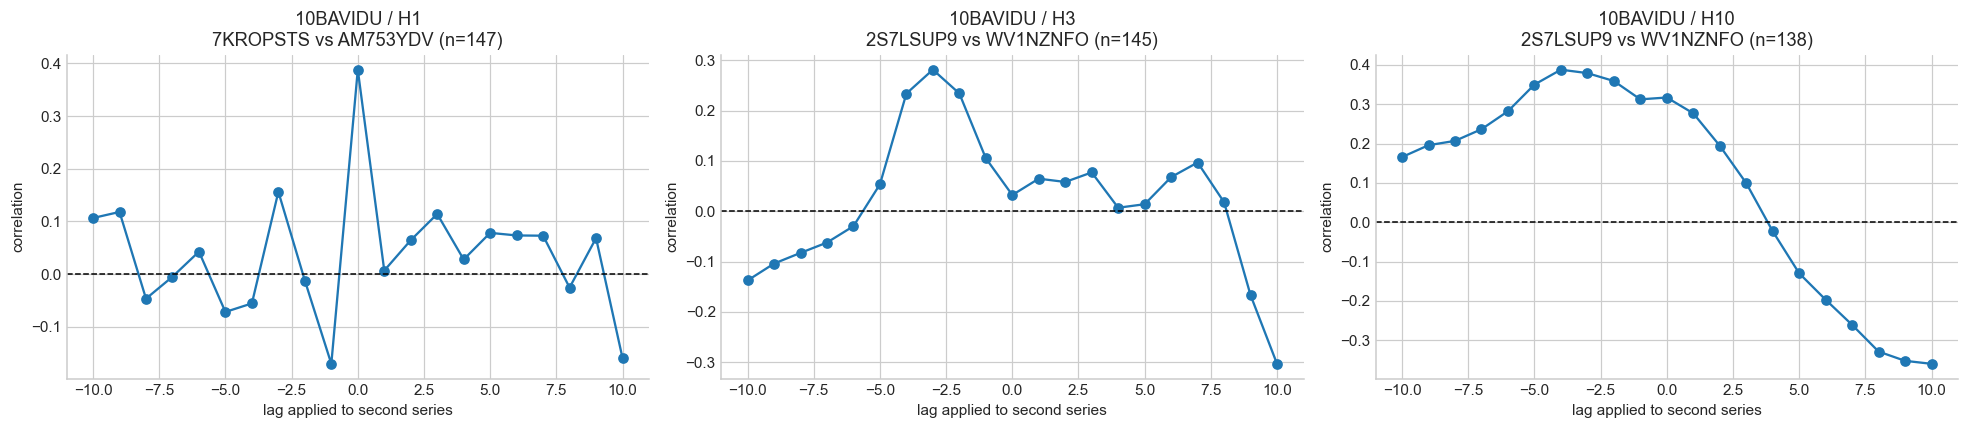

In [21]:
pair_candidates = []
for (code_value, horizon_value), grp in train.groupby(['code', 'horizon']):
    pivot = grp.pivot_table(index='ts_index', columns='sub_code', values='y_target', aggfunc='mean')
    if pivot.shape[1] < 2:
        continue
    cols = list(pivot.columns)
    best = None
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            overlap = pivot[[cols[i], cols[j]]].dropna().shape[0]
            if best is None or overlap > best[0]:
                best = (overlap, cols[i], cols[j])
    if best and best[0] > 50:
        pair_candidates.append((code_value, horizon_value, pivot, best[1], best[2], best[0]))
    if len(pair_candidates) == 3:
        break

fig, axes = plt.subplots(1, len(pair_candidates), figsize=(6 * len(pair_candidates), 4))
axes = np.atleast_1d(axes)
for ax, (code_value, horizon_value, pivot, c1, c2, overlap) in zip(axes, pair_candidates):
    s1 = pivot[c1]
    s2 = pivot[c2]
    lags = range(-10, 11)
    corrs = []
    for lag in lags:
        aligned = pd.concat([s1, s2.shift(lag)], axis=1).dropna()
        if len(aligned) > 3 and aligned.iloc[:, 0].nunique() > 1 and aligned.iloc[:, 1].nunique() > 1:
            corrs.append(aligned.corr().iloc[0, 1])
        else:
            corrs.append(np.nan)
    ax.plot(list(lags), corrs, marker='o')
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set_title(f'{code_value} / H{horizon_value}\n{c1} vs {c2} (n={overlap})')
    ax.set_xlabel('lag applied to second series')
    ax.set_ylabel('correlation')
plt.tight_layout()
plt.show()


Cross-series dependence is present in at least some buckets, although it is far from uniform. That supports global modeling and cross-series sharing, but it does not justify naive pooling without panel identifiers.


## 10. Leakage and split sanity checks

Before leaving EDA, we should verify that the split logic is explicit and that no obvious schema-level leakage is hiding inside the shared columns.


In [22]:
split_check = pd.DataFrame({
    'partition': ['train_pre_cutoff', 'train_post_cutoff', 'test'],
    'row_count': [
        int((train['ts_index'] <= VAL_CUTOFF).sum()),
        int((train['ts_index'] > VAL_CUTOFF).sum()),
        int(len(test)),
    ],
})
print('train-only columns:', sorted(set(train.columns) - set(test.columns)))
print('test-only columns:', sorted(set(test.columns) - set(train.columns)))
split_check


train-only columns: ['weight', 'y_target']
test-only columns: []


,partition,row_count
0,train_pre_cutoff,4121749
1,train_post_cutoff,1215665
2,test,1447107


In [23]:
probabilistic_artifacts_present = any(
    token in col.lower()
    for col in train.columns
    for token in ['lower', 'upper', 'quant', 'interval', 'q10', 'q90']
)
print({'probabilistic_columns_in_raw_train': probabilistic_artifacts_present})
print('The raw dataset and current project workflow are point-forecast oriented; prediction intervals are not present here.')


{'probabilistic_columns_in_raw_train': False}
The raw dataset and current project workflow are point-forecast oriented; prediction intervals are not present here.


Schema-level leakage is not obvious from the raw columns: the only train-only fields are `y_target` and `weight`, which is what we expect. Just as important, the current project has no raw or saved probabilistic outputs, so any interval analysis would need to be added intentionally later rather than assumed to exist.


## 11. EDA conclusions for modeling

The notebook should end by making downstream modeling decisions easier, not by repeating the plots. These are the practical conclusions that the later notebooks should inherit.


**Modeling implications**

- Use global models, not only local single-series baselines, because the panel is heterogeneous and cross-series sharing is plausible.
- Keep classical models as methodological baselines, but do not expect them to exploit the full 86-feature structure.
- Use weighted evaluation consistently because a small share of rows carries a large share of the metric influence.
- Preserve strict temporal splitting around `VAL_CUTOFF = 2880`, since only a minority of series cleanly cross that boundary.
- Treat train/test support mismatch as real: test covers fewer `sub_code`s, so robustness matters more than overfitting to dense train-only entities.
- The current project is point-forecast only. If later notebooks need interval bands, `PICP`, `MPIW`, or quantile forecasts, that requires a dedicated probabilistic forecasting layer rather than a plotting tweak.
